Ячейка 1

In [1]:
from pathlib import Path
import re, html, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack

import pymorphy3, nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)

PREP = Path("../data/prepared_datasets")
SEED = 42
BEST_C = 0.04961947603002903  # HalvingRandomSearch, все 3 фолда
morph = pymorphy3.MorphAnalyzer()
KEEP = {"не", "нет", "ни", "без", "нельзя"}
STOP = (set(stopwords.words("russian")) | set(stopwords.words("english"))) - KEEP
CYR = re.compile(r"[а-яе]")
print("best model: LinearSVC  C =", BEST_C)

best model: LinearSVC  C = 0.04961947603002903


Ячейка 2

In [2]:
TAG = re.compile(r"<[^>]+>")
JUNK = re.compile(r"&(?:quot|amp|lt|gt|nbsp|#\d+);", re.I)
WORD = re.compile(r"[a-zа-яё0-9]+", re.I)

def clean(text: str) -> str:
    s = html.unescape(str(text))
    s = JUNK.sub(" ", s)
    s = TAG.sub(" ", s)
    s = s.lower().replace("ё", "е")
    toks = []
    for w in WORD.findall(s):
        if w.isdigit() or len(w) < 2:
            continue
        if CYR.search(w) and w not in KEEP:
            w = morph.parse(w)[0].normal_form
        if w not in STOP:
            toks.append(w)
    return " ".join(toks)

def load(name):
    df = pd.read_csv(PREP / name)
    df = df.dropna(subset=["text", "label"]).copy()
    df["label"] = df["label"].astype(int)
    df["text_clean"] = df["text"].map(clean)
    return df[df["text_clean"].str.len() > 0].reset_index(drop=True)

train = load("final_train.csv")
test = load("final_test.csv")
print("train", train.shape, "test", test.shape)

train (54321, 7) test (13580, 7)


Ячейка 3

In [3]:
fit_df, val_df = train_test_split(train, test_size=0.15, stratify=train["label"], random_state=SEED)

def vectorize(a, b):
    word = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=120_000, sublinear_tf=True)
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=120_000, sublinear_tf=True)
    Xa = hstack([word.fit_transform(a), char.fit_transform(a)]).tocsr()
    Xb = hstack([word.transform(b), char.transform(b)]).tocsr()
    return word, char, Xa, Xb

word_v, char_v, X_fit, X_val = vectorize(fit_df["text_clean"], val_df["text_clean"])
clf_thr = LinearSVC(C=BEST_C, class_weight="balanced", max_iter=8000, random_state=SEED)
clf_thr.fit(X_fit, fit_df["label"])
val_score = clf_thr.decision_function(X_val)

grid = np.quantile(val_score, np.linspace(0.02, 0.98, 49))
best_t, best_a = grid[0], -1
for t in grid:
    a = accuracy_score(val_df["label"], val_score >= t)
    if a > best_a:
        best_t, best_a = t, a
print(f"порог {best_t:.4f}  val acc {best_a:.3f}")

word, char, Xtr, Xte = vectorize(train["text_clean"], test["text_clean"])
clf = LinearSVC(C=BEST_C, class_weight="balanced", max_iter=8000, random_state=SEED)
clf.fit(Xtr, train["label"])
score = clf.decision_function(Xte)
pred = (score >= best_t).astype(int)

порог 0.0791  val acc 0.747


Ячейка 4

In [4]:
y = test["label"].values
acc = accuracy_score(y, pred)
n = len(y)
z = 1.96
den = 1 + z**2 / n
center = (acc + z**2 / (2 * n)) / den
half = z * np.sqrt(acc * (1 - acc) / n + z**2 / (4 * n**2)) / den
lo, hi = center - half, center + half

print(f"TEST accuracy {acc:.3f}")
print(f"95% CI [{lo:.3f}, {hi:.3f}]")
print(f"macro F1 {f1_score(y, pred, average='macro'):.3f}")
print(f"F1 fake {f1_score(y, pred, pos_label=1):.3f}")
print(classification_report(y, pred, digits=3, zero_division=0))

TEST accuracy 0.751
95% CI [0.744, 0.758]
macro F1 0.744
F1 fake 0.702
              precision    recall  f1-score   support

           0      0.765     0.809     0.786      7681
           1      0.731     0.676     0.702      5899

    accuracy                          0.751     13580
   macro avg      0.748     0.742     0.744     13580
weighted avg      0.750     0.751     0.750     13580



Ячейка 5

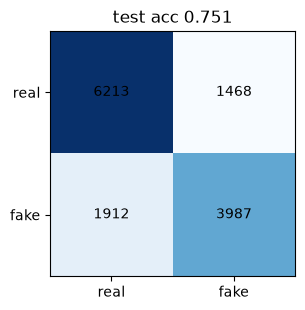

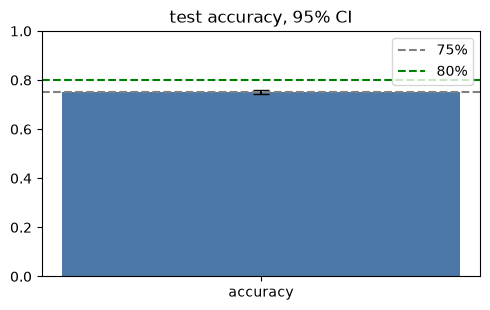

In [5]:
cm = confusion_matrix(y, pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(3.4, 3.2))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["real", "fake"]); ax.set_yticklabels(["real", "fake"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
ax.set_title(f"test acc {acc:.3f}")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["accuracy"], [acc], color="#4C78A8")
ax.errorbar([0], [acc], yerr=[[acc - lo], [hi - acc]], fmt="none", ecolor="black", capsize=6)
ax.axhline(0.75, color="gray", ls="--", label="75%")
ax.axhline(0.80, color="green", ls="--", label="80%")
ax.set_ylim(0, 1); ax.legend(); ax.set_title("test accuracy, 95% CI")
plt.tight_layout(); plt.show()

Ячейка 6

In [6]:
bad = test[pred != y].copy()
bad["pred"] = pred[pred != y]
print("ошибок", len(bad))
print(bad.groupby("source").size().sort_values(ascending=False).head(10))
print("\nпримеры:")
print(bad[["source", "label", "pred", "text"]].head(8).to_string(index=False))

ошибок 3380
source
onion_huffpost     1455
pubhealth_train     618
gossipcop           576
danya_train         212
train_stances       188
pubhealth_test       90
pubhealth_dev        86
panorama             72
test_stances         49
nplus1               34
dtype: int64

примеры:
         source  label  pred                                                                                                 text
 pubhealth_test      0     1                    Розанна Барр выступила Гитлером за выпуск сатирического еврейского журнала "Хиб".
pubhealth_train      1     0                    Здоровая диета поможет пациентам, страдающим почечными заболеваниями, жить дольше
 onion_huffpost      0     1                            Парализованная собака не может быть счастлива получить второй шанс ходить
 onion_huffpost      0     1                                                                      моей бабушке после смерти отца.
 onion_huffpost      0     1                                    Барр